# Data Quality Assessment & Cleaning — CustomerAddress

**Table:** `CustomerAddress` — 3,999 addresses, one per customer.

The smallest of the four tables and the cleanest, but it carries the join that the whole
project depends on. Two issues: state names recorded inconsistently, and customer IDs that
do not line up with the demographics table.

The second one matters more than it looks. Every customer lost on this join disappears from
the map and from every state-level figure, so it needs to be counted and decided rather than
noticed and moved past.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_excel('Raw_data.xlsx', sheet_name='CustomerAddress')
print(f'{df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

3,999 rows x 6 columns


,customer_id,address,postcode,state,country,property_valuation
0,1,060 Morning Avenue,2016,New South Wales,Australia,10
1,2,6 Meadow Vale Court,2153,New South Wales,Australia,10
2,4,0 Holy Cross Court,4211,QLD,Australia,9
3,5,17979 Del Mar Point,2448,New South Wales,Australia,4
4,6,9 Oakridge Court,3216,VIC,Australia,9


## 1. First look

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         3999 non-null   int64 
 1   address             3999 non-null   object
 2   postcode            3999 non-null   int64 
 3   state               3999 non-null   object
 4   country             3999 non-null   object
 5   property_valuation  3999 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 187.6+ KB


In [3]:
print('missing values:', df.isna().sum().sum())
print('duplicate rows:', df.duplicated().sum())
print('duplicate customer_id:', df['customer_id'].duplicated().sum())

missing values: 0
duplicate rows: 0
duplicate customer_id: 0


No missing values and no duplicates. `customer_id` is unique, so it is a valid join key.

That is unusually clean — which is worth saying rather than skipping, because it means the
effort here goes on the two real problems instead of on imputation.

## 2. Issue: state is not standardised

The same state is recorded both as an abbreviation and as a full name.

In [4]:
df['state'].value_counts()

state
NSW                2054
VIC                 939
QLD                 838
New South Wales      86
Victoria             82
Name: count, dtype: int64

Five values for three states. `New South Wales` and `NSW` are the same place, as are
`Victoria` and `VIC`.

Left alone, every state chart would show five bars instead of three, and NSW would appear
to have 2,054 customers when it actually has 2,140.

**Action:** map the long forms onto the abbreviations. Abbreviations are chosen over full
names because they are the majority form and they fit on a chart axis.

In [5]:
state_map = {
    'New South Wales': 'NSW',
    'Victoria': 'VIC',
    'NSW': 'NSW', 'VIC': 'VIC', 'QLD': 'QLD',
}
df['state'] = df['state'].map(state_map)

print('unmapped values left:', df['state'].isna().sum())
df['state'].value_counts()

unmapped values left: 0


state
NSW    2140
VIC    1021
QLD     838
Name: count, dtype: int64

Three states, as expected. Only NSW, VIC and QLD appear — this business does not operate in
the other five Australian states and territories, which is a fact about the company rather
than a data problem.

## 3. Check: country and postcode

In [6]:
print('countries:', df['country'].unique())
print('postcode range:', df['postcode'].min(), '-', df['postcode'].max())
print('property_valuation range:', df['property_valuation'].min(), '-', df['property_valuation'].max())

countries: ['Australia']
postcode range: 2000 - 4883
property_valuation range: 1 - 12


`country` is `Australia` for every row, so it carries no information and no filter will ever
use it. It is kept rather than dropped because the Tableau map expects a country field, and
one constant column costs nothing.

Postcodes run 2000–4883, which is the correct range for NSW, VIC and QLD. `property_valuation`
is an ordinal 1–12 score, already clean.

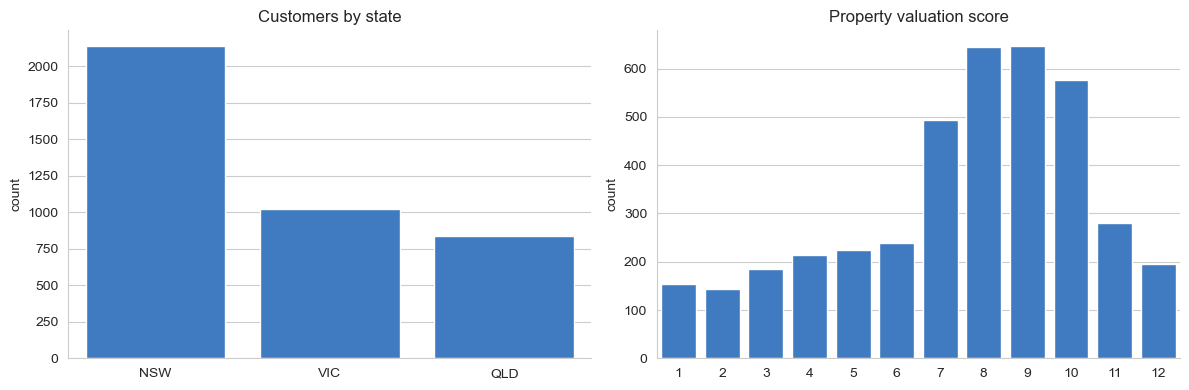

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='state', order=df['state'].value_counts().index,
              color='#2a78d6', ax=axes[0])
axes[0].set_title('Customers by state')
axes[0].set_xlabel('')

sns.countplot(data=df, x='property_valuation', color='#2a78d6', ax=axes[1])
axes[1].set_title('Property valuation score')
axes[1].set_xlabel('')

sns.despine()
plt.tight_layout()
plt.show()

## 4. Issue: the tables do not line up

This is the one that would quietly cost customers. Compare the IDs in this table against the
cleaned demographics table.

In [8]:
demo = pd.read_csv('CustomerDemographic_Cleaned.csv')

demo_ids = set(demo['customer_id'])
addr_ids = set(df['customer_id'])

only_demo = sorted(demo_ids - addr_ids)
only_addr = sorted(addr_ids - demo_ids)

print(f'customers in demographics: {len(demo_ids):,}')
print(f'customers in address:      {len(addr_ids):,}')
print(f'in demographics but NO address: {len(only_demo)}  {only_demo}')
print(f'in address but NO demographics: {len(only_addr)}  {only_addr}')

customers in demographics: 3,997
customers in address:      3,999
in demographics but NO address: 4  [3, 10, 22, 23]
in address but NO demographics: 6  [34, 753, 3790, 4001, 4002, 4003]


Two different problems, and they need different answers.

**Four customers have no address: 3, 10, 22, 23.** They are real customers with real
demographics who may well have transactions. An inner join would delete them silently.

**Six addresses have no customer.** Three of them — 34, 753 and 3790 — are the records this
project removed in the previous notebook: the customer born in 1843 and the two deceased
customers. Their addresses are correctly orphaned as a consequence of our own cleaning.

The other three — 4001, 4002, 4003 — are addresses for customers who were never in the
demographics extract at all.

In [9]:
# Confirm the three orphans are the ones we removed ourselves.
raw_demo = pd.read_excel('Raw_data.xlsx', sheet_name='CustomerDemographic')
removed_by_us = set(raw_demo['customer_id']) - demo_ids

print('IDs removed during demographic cleaning:', sorted(removed_by_us))
print('of the orphan addresses, removed by us:', sorted(set(only_addr) & removed_by_us))
print('genuinely extra addresses:              ', sorted(set(only_addr) - removed_by_us))

IDs removed during demographic cleaning: [34, 753, 3790]
of the orphan addresses, removed by us: [34, 753, 3790]
genuinely extra addresses:               [4001, 4002, 4003]


### Decision

**Keep the four address-less customers, and use a LEFT join from demographics.**

They have demographics and they may have transactions, so they belong in the RFM model and in
the total customer count. They will have no state or postcode, which means they simply do not
appear on the map — the right outcome, since we genuinely do not know where they are.

An inner join would have been easier and would have lost four paying customers without a word.

**Drop the three genuinely extra addresses (4001–4003).** An address with no customer behind it
cannot be segmented, marketed to, or counted.

In [10]:
df = df[df['customer_id'].isin(demo_ids)]
print(f'{len(df):,} addresses remain (matched to a cleaned customer)')

# Show the effect of the join choice.
inner = demo.merge(df, on='customer_id', how='inner')
left  = demo.merge(df, on='customer_id', how='left')
print(f'\ninner join -> {len(inner):,} customers')
print(f'left join  -> {len(left):,} customers  (4 with no address)')

3,993 addresses remain (matched to a cleaned customer)

inner join -> 3,993 customers
left join  -> 3,997 customers  (4 with no address)


## 5. Cleaned output

In [11]:
print(f'{len(df):,} rows x {df.shape[1]} columns')
print('nulls:', df.isna().sum().sum())
df.head()

3,993 rows x 6 columns
nulls: 0


,customer_id,address,postcode,state,country,property_valuation
0,1,060 Morning Avenue,2016,NSW,Australia,10
1,2,6 Meadow Vale Court,2153,NSW,Australia,10
2,4,0 Holy Cross Court,4211,QLD,Australia,9
3,5,17979 Del Mar Point,2448,NSW,Australia,4
4,6,9 Oakridge Court,3216,VIC,Australia,9


In [12]:
df.to_csv('CustomerAddress_Cleaned.csv', index=False)
print('saved CustomerAddress_Cleaned.csv')

saved CustomerAddress_Cleaned.csv


## Summary of changes

| # | Issue | Action | Records affected |
|---|---|---|---|
| 1 | State recorded as both `NSW` and `New South Wales` | standardised to abbreviations | 168 |
| 2 | 3 addresses with no matching customer | removed | 3 |

**Found and decided, not changed:** four customers (3, 10, 22, 23) have no address. They are
kept, and the customer table is joined with a LEFT join so they survive into the analysis. They
will be absent from state and map views only.

**Checked and clean:** no missing values, no duplicates, `customer_id` unique, postcodes inside
the correct range for the three states, `property_valuation` a valid 1–12 ordinal.

**Note on `country`:** constant at `Australia`. Kept because the map needs it, not because it
carries information.